In [1]:
import os
os.chdir(r"C:\Users\Alraian Abdelrahim\Stats models DS\Final Project")

In [63]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

## Helped Functions

In [ ]:
# function that does the original transformations
# put 1 if want the transformation

def original_transformations(df, vs, yc, ceHR, ceDOW, ceMOY, subSex, subRace):

    if vs == 1:
        df['violation_severity'] = df['violation_severity'].astype('category')

    if yc == 1:
        df["year_cat"] = df["year"].astype("category")

    if ceHR == 1:
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    if ceDOW == 1:
        df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
        df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    
    if ceMOY == 1:
        df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
        df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    if subSex == 1:
        df['subject_sex'] = pd.Categorical(df['subject_sex'])
        df['subject_sex'] = pd.Categorical(
            df['subject_sex'],
            categories=['male','female','Unknown'],
            ordered=False
        )

    if subRace == 1:
        df['subject_race'] = pd.Categorical(df['subject_race'])
        df['subject_race'] = pd.Categorical(
            df['subject_race'],
            categories=['white','black','asian/pacific islander','other','unknown'],
            ordered=False
        )

    return df

def cat_dummy_vif_check(df):
    # grab the categorical columns and make them into dummies
    catVars = df.select_dtypes(include = ['object', 'category']).columns
    dummies = pd.get_dummies(df[catVars], drop_first=True, dtype = int)

    # check VIF
    vif_data = pd.DataFrame()
    vif_data["feature"] = dummies.columns

    vif_data["VIF"] = [variance_inflation_factor(dummies.values, i) for i in range(len(dummies.columns))]

    # keep only the good columns
    colsKeep = vif_data[vif_data["VIF"] < 10]['feature'].tolist()

    return dummies, colsKeep


In [69]:
# function to run model

def model_run(df):
    X = df.drop(columns = ['disposition_severity'])
    y = df['disposition_severity']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,      # 25% test, 75% train 
        random_state=42,     # for reproducibility
        stratify=y           # keeps outcome class distribution similar in train/test
    )

    # scale - fit on train ONLY anad scale both
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # add constant -> Adds the intercept column after scaling
    X_train_final = sm.add_constant(X_train_scaled)
    X_test_final = sm.add_constant(X_test_scaled)

    # fit binomial GLM -> family=sm.families.Binomial() defaults to the Logit link function
    model = sm.GLM(y_train, X_train_final, sm.families.Binomial()).fit()

    variable_labels = ['Intercept'] + X.columns.tolist()

    print("Training AIC:", model.aic)
    print("Training BIC:", model.bic)
    print(model.summary(xname=variable_labels))

    return model, scaler, X_test_final, y_test

In [81]:
# out of sample metrics + predictive performance

def oos_metrics(model, X_test_final, y_test):
    # Predict probabilities and class labels (thr=0.5)
    y_pred_prob = model.predict(X_test_final)
    threshold = 0.5
    y_pred = (y_pred_prob >= threshold).astype(int)

    # confusion matrix and components
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)            # TPR
    specificity = tn / (tn + fp)                     # TNR
    fpr = fp / (fp + tn)                        # False Positive Rate
    fnr = fn / (fn + tp)                             # False Negative Rate
    f1 = f1_score(y_test, y_pred)
    balanced_accuracy = (recall + specificity) / 2
    auc = roc_auc_score(y_test, y_pred_prob)

    print(f'Threshold: {threshold}\n Accuracy: {accuracy}\n Precision: {precision}\n Recall: {recall}\n Specificity: {specificity}')
    print(f' FP Rate: {fpr}\n FN Rate: {fnr}\n F1-Score: {f1}\n Balanced Accuracy: {balanced_accuracy}\n ROC-AUC: {auc}')

    # heatmap
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
        ax=axes[0]
    )
    axes[0].set_title(f"Confusion Matrix (Threshold = {threshold})")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", label=f"Random Guessing")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()


    plt.tight_layout()
    plt.show()


    

## Load the Data

In [18]:
# load the cleaned data

df = pd.read_csv("WichitaCleanDf.csv")
df = df.drop(columns = ['Unnamed: 0'])

In [4]:
# double checking there are no na vals

nullDf = []
null_data = df.isnull().sum()

# calculate percentages
percentages = (null_data / len(df)) * 100

# Create summary DataFrame
nullDf = pd.DataFrame({'Column': null_data.index,'Count': null_data.values,'Percentage': percentages.values})

print(nullDf.sort_values('Count', ascending=False))

                                 Column  Count  Percentage
0                    subject_race_black      0         0.0
1   subject_race_asian/pacific islander      0         0.0
2                    subject_race_other      0         0.0
3                    subject_sex_female      0         0.0
4                   vehicle_tier_LEGACY      0         0.0
5                   vehicle_tier_LUXURY      0         0.0
6                      vehicle_tier_MID      0         0.0
7               vehicle_tier_MOTORCYCLE      0         0.0
8                  vehicle_tier_TRAILER      0         0.0
9                  vehicle_tier_UNKNOWN      0         0.0
10               violation_severity_2.0      0         0.0
11               violation_severity_3.0      0         0.0
12                   city_location_east      0         0.0
13                  city_location_north      0         0.0
14                  city_location_south      0         0.0
15                city_location_unknown      0         0

## Model Run (Baseline)

In [70]:
model, scaler, X_test_final, y_test  = model_run(df)

Training AIC: 38829.94407248929
Training BIC: 39111.548621584094
                  Generalized Linear Model Regression Results                   
Dep. Variable:     disposition_severity   No. Observations:                65122
Model:                              GLM   Df Residuals:                    65091
Model Family:                  Binomial   Df Model:                           30
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -19384.
Date:                  Wed, 16 Sep 2026   Deviance:                       38768.
Time:                          00:58:36   Pearson chi2:                 6.48e+04
No. Iterations:                       6   Pseudo R-squ. (CS):            0.02914
Covariance Type:              nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------

Threshold: 0.5
 Accuracy: 0.9056569006817763
 Precision: 0.9056569006817763
 Recall: 1.0
 Specificity: 0.0
 FP Rate: 1.0
 False Negative Rate: 0.0
 F1 Score: 0.9504931347901759
 Balanced Accuracy:0.5
 ROC-AUC: 0.6769912611067841


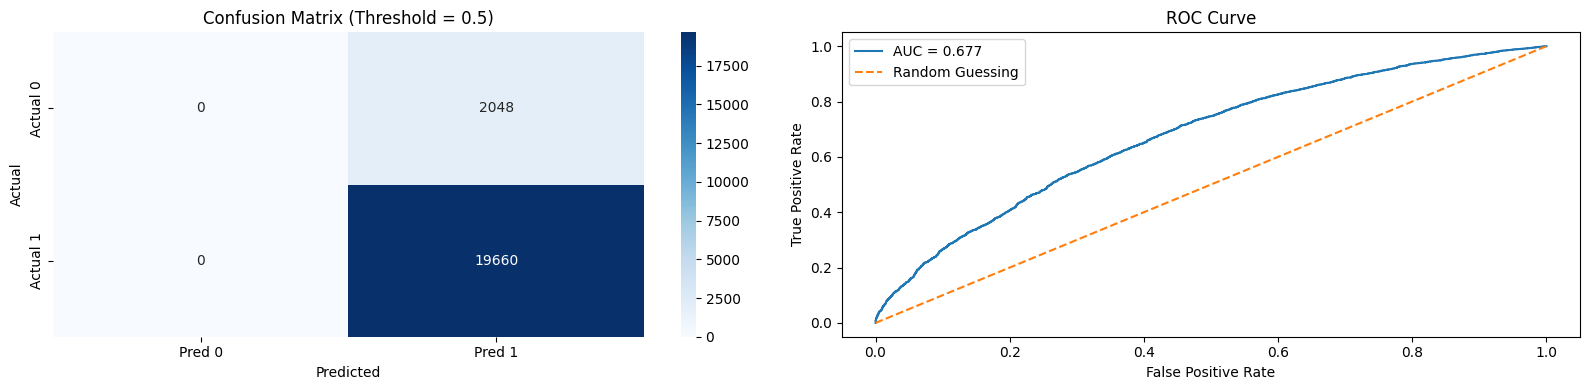

In [80]:
# out of sample metrics

oos_metrics(model, X_test_final, y_test)

### Other Model Attempts

In [37]:
# bringing back data before transformations
dfOg = pd.read_csv("cleanedWichita.csv")
dfOg = dfOg.drop(columns = ["Unnamed: 0"])

In [82]:
# attempt 2: make age 65+ as the baseline since coeff close to zero 

df2 = dfOg.copy()

df2New = original_transformations(df2,1,1,1,1,1,1,1)

# change the order of age so baseline is 65+
df2New['age_category'] = pd.Categorical(df2New['age_category'])
df2New['age_category'] = pd.Categorical(df2New['age_category'],
    categories=['65+','16-24', '25-34', 'Unknown', '35-54', '55-64'], ordered=False)

# categorize and make dummies + check VIF and only keep the clean
dummies, colsKeep = cat_dummy_vif_check(df2New)

# final dataset 
result = pd.concat([
    dummies[colsKeep],
    df2New[["disposition_severity", "hour_sin", "hour_cos", 
                 "month_sin", "month_cos", "dow_sin", "dow_cos"]]
], axis=1)

model, scaler, X_test_final, y_test  = model_run(result)

Training AIC: 38829.94407248929
Training BIC: 39111.548621584094
                  Generalized Linear Model Regression Results                   
Dep. Variable:     disposition_severity   No. Observations:                65122
Model:                              GLM   Df Residuals:                    65091
Model Family:                  Binomial   Df Model:                           30
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -19384.
Date:                  Wed, 16 Sep 2026   Deviance:                       38768.
Time:                          01:06:36   Pearson chi2:                 6.48e+04
No. Iterations:                       6   Pseudo R-squ. (CS):            0.02914
Covariance Type:              nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------

Threshold: 0.5
 Accuracy: 0.9056569006817763
 Precision: 0.9056569006817763
 Recall: 1.0
 Specificity: 0.0
 FP Rate: 1.0
 FN Rate: 0.0
 F1-Score: 0.9504931347901759
 Balanced Accuracy: 0.5
 ROC-AUC: 0.6769912611067841


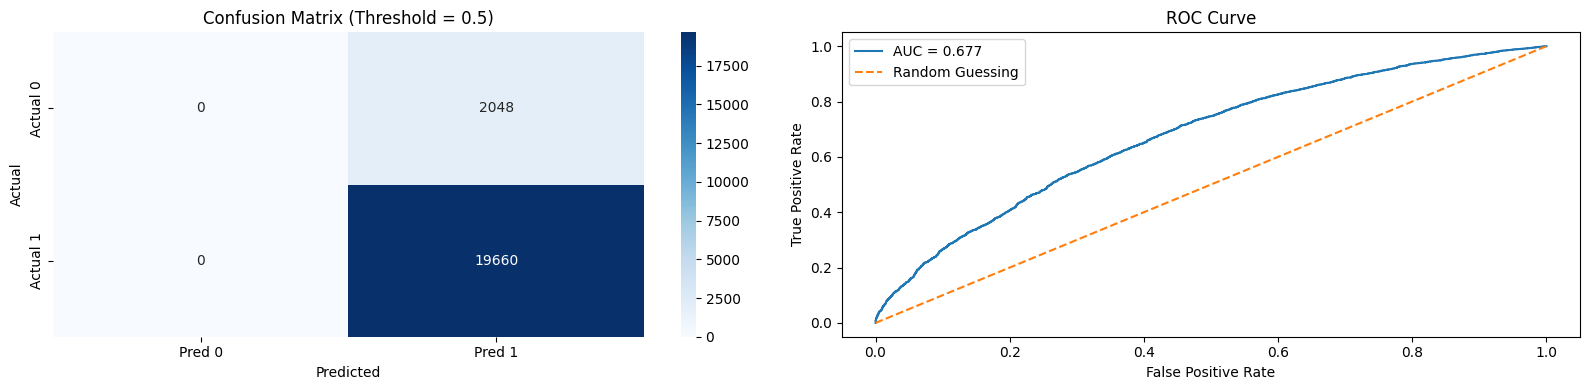

In [83]:
# out of sample metrics

oos_metrics(model, X_test_final, y_test)

In [ ]:


# dropping age category 65+ since the value is close to zero and statistically insignificant
indicesToDrop = df[df['age_category_65+'] == 1].index
df2 = df2.drop(indicesToDrop)

# will try combining the vehicle categories with harsher enforcements 
# vehicle subcategories with stricter enforcements were moved into their own group "other"
df2['vehicle_tier_other'] = df2['vehicle_tier_MOTORCYCLE'] | df2['vehicle_tier_TRAILER'] | df2['vehicle_tier_LEGACY']


df2 = df2.drop(columns = ['vehicle_tier_MOTORCYCLE','vehicle_tier_TRAILER','vehicle_tier_LEGACY', 'age_category_65+'])

In [28]:
X2 = df2.drop(columns = ['disposition_severity'])
y2 = df2['disposition_severity']

# train test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.25,      # 25% test, 75% train 
    random_state=42,     # for reproducibility
    stratify=y2           # keeps outcome class distribution similar in train/test
)

# scale - fit on train ONLY anad scale both
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

# add constant -> Adds the intercept column after scaling
X_train_final2 = sm.add_constant(X_train_scaled2)
X_test_final2 = sm.add_constant(X_test_scaled2)

model2 = sm.GLM(y_train2, X_train2, sm.families.Binomial()).fit()

print("Training AIC:", model2.aic)
print("Training Log-Likelihood:", model2.llf)

print(model2.summary())

Training AIC: 38087.777446574306
Training Log-Likelihood: -19016.888723287153
                  Generalized Linear Model Regression Results                   
Dep. Variable:     disposition_severity   No. Observations:                61181
Model:                              GLM   Df Residuals:                    61154
Model Family:                  Binomial   Df Model:                           26
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -19017.
Date:                  Tue, 15 Sep 2026   Deviance:                       38034.
Time:                          23:13:10   Pearson chi2:                 6.92e+04
No. Iterations:                       6   Pseudo R-squ. (CS):           0.005338
Covariance Type:              nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
--------

In [ ]:
print("Training AIC:", model.aic)
print("Training Log-Likelihood:", model.llf)

## Out of Sample Predictive Performance + Metrics

In [ ]:


## ATTEMPT 1

